In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import os #run this if running on a remote server!

os.environ['QT_QPA_PLATFORM'] = 'offscreen'

In [3]:
import sys
sys.path.append('../')
from utility.file_utility import FileUtility

In [4]:
#from data_preprocessing.positive_negative_sampling import DataSampling

#datasampling =DataSampling()
#cluster_ids = datasampling.cluster_sampling

# Running DiMotif step-by-step

<img src="../DiMotif.pdf">

Files containing positive and negative sequences (a sequence per line)

## (i) Sequence segmentation

The segmentation can be applied based on the segmentation learned from Swiss-Prot database (general-purpose) or from the positive set (domain-specific)

### Loading Swiss-Prot Segmentation

We need to load the alpha distribution for segmentation sampling from the file.

In [5]:
import scipy.stats as st
import numpy as np
import tqdm
from utility.math_utility import normalize_mat


swiss_size_change=FileUtility.load_obj('../data_config/swiss_1000_samples.pickle')
all_samples=[]
for i in tqdm.tqdm(range(0,1000)):
    sample=[]
    for vocab in np.arange(10000,1000000,10000):
        sample.append(swiss_size_change[vocab][i])
    all_samples.append(-np.diff(sample))

sample_mat=np.mean(normalize_mat(all_samples),axis=0)
sample_mat_std=np.std(normalize_mat(all_samples),axis=0)
alpha_param = st.alpha.fit(sample_mat)

100%|███████████████████████████████| 1000/1000 [00:00<00:00, 88994.36it/s]


Then we sample from the alpha distribution:

In [6]:
# number of segmentation to be used

segmentation_schemes=10
r = st.alpha.rvs(alpha_param[0], size=segmentation_schemes)
vocab_sizes=np.array(np.round(10000+(r*10000)),dtype=np.int32).tolist()
vocab_sizes.sort()

# vocabulary sizes seen from Swiss-Prot
vocab_sizes

[13827, 14035, 14256, 14335, 16259, 17709, 18171, 25245, 27455, 73098]

number of cores to be used 2
Loaded and processed positive and negative ferredoxin samples for cluster 1Loaded and processed positive and negative ferredoxin samples for cluster 0

Beginning segmentation of sequences in cluster 1Beginning segmentation of sequences in cluster 0



10it [02:50, 17.00s/it]


Completed segmentation of sequences in cluster 1
Starting segmentation of sequences for cluster 1


/home/ss307/miniforge3/envs/dimotif/lib/python3.12/site-packages/sklearn/feature_extraction/text.py:527: UserWarning: The parameter 'token_pattern' will not be used since 'tokenizer' is not None'
  warnings.warn(
10it [02:50, 17.06s/it]


Completed segmentation of sequences in cluster 0
Starting segmentation of sequences for cluster 0


/home/ss307/miniforge3/envs/dimotif/lib/python3.12/site-packages/sklearn/feature_extraction/text.py:527: UserWarning: The parameter 'token_pattern' will not be used since 'tokenizer' is not None'
  warnings.warn(



motif 	 p-value
cac 	 0.0 	 1
dk 	 0.0 	 1
aw 	 0.0 	 1
ace 	 0.0 	 1
tin 	 0.0 	 1
ky 	 0.0 	 1
tt 	 0.0 	 1
ip 	 0.0 	 1
ph 	 0.0 	 1
glep 	 0.0 	 1
ipky 	 0.0 	 1
mldk 	 0.0 	 1
peg 	 0.0 	 1
ieh 	 0.0 	 1
vreg 	 0.0 	 1
vve 	 0.0 	 1
h 	 0.0 	 1
gle 	 0.0 	 1
cpeg 	 0.0 	 1
ks 	 0.0 	 1
vveip 	 0.0 	 1
ieie 	 0.0 	 1
cq 	 0.0 	 1
slee 	 0.0 	 1
hak 	 0.0 	 1
draw 	 0.0 	 1
en 	 0.0 	 1
cpdg 	 0.0 	 1
ch 	 0.0 	 1
slne 	 0.0 	 1
mp 	 0.0 	 1
hac 	 0.0 	 1
dll 	 0.0 	 1
vlph 	 0.0 	 1
nh 	 0.0 	 1
ireg 	 0.0 	 1
rls 	 0.0 	 1
dedl 	 0.0 	 1
fd 	 0.0 	 1
acgg 	 0.0 	 1
flp 	 0.0 	 1
pes 	 0.0 	 1
ice 	 0.0 	 1
kys 	 0.0 	 1
cp 	 0.0 	 1
lldk 	 0.0 	 1
avle 	 0.0 	 1
hare 	 0.0 	 1
vi 	 0.0 	 1
adel 	 0.0 	 1
Creating dendogram for k-mers in cluster 1


/home/ss307/miniforge3/envs/dimotif/lib/python3.12/site-packages/scipy/cluster/hierarchy/_hierarchy_impl.py:247: ClusterWarning: The symmetric non-negative hollow observation matrix looks suspiciously like an uncondensed distance matrix
  return linkage(y, method='complete', metric='euclidean')


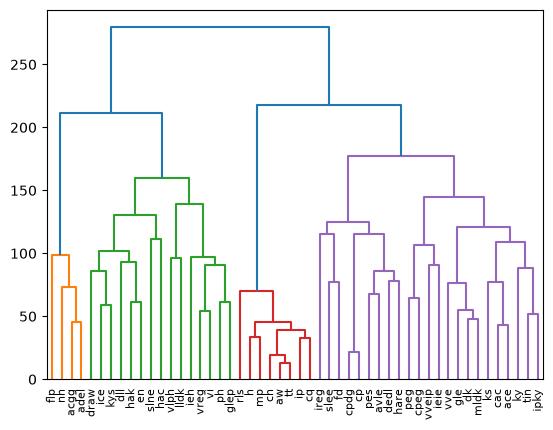


motif 	 p-value
crag 	 0.0 	 0
vay 	 0.0 	 0
cag 	 0.0 	 0
cr 	 0.0 	 0
qsd 	 0.0 	 0
ag 	 0.0 	 0
fldd 	 0.0 	 0
th 	 0.0 	 0
pys 	 0.0 	 0
aaee 	 0.0 	 0
ys 	 0.0 	 0
ykv 	 0.0 	 0
wp 	 0.0 	 0
caa 	 0.0 	 0
yil 	 0.0 	 0
ild 	 0.0 	 0
yvl 	 0.0 	 0
tc 	 0.0 	 0
ngtc 	 0.0 	 0
dlp 	 0.0 	 0
ch 	 0.0 	 0
rls 	 0.0 	 0
qs 	 0.0 	 0
qfg 	 0.0 	 0
tsd 	 0.0 	 0
crng 	 0.0 	 0
cvs 	 0.0 	 0
mat 	 1.1181273886778442e-306 	 0
fvl 	 1.7946627201006452e-306 	 0
cq 	 1.1646905008208784e-296 	 0
fld 	 2.563457179327568e-292 	 0
yall 	 7.1231923388017405e-292 	 0
yt 	 8.251410114739134e-290 	 0
tvd 	 3.6965587988351655e-282 	 0
ddd 	 7.280669355561357e-281 	 0
css 	 2.582555661736334e-275 	 0
cgg 	 7.7249727365142425e-264 	 0
cvay 	 6.667722980220386e-258 	 0
vctt 	 1.017025595489939e-248 	 0
pc 	 8.973634718960751e-231 	 0
idl 	 1.3096722650031705e-226 	 0
acss 	 4.2876097030567766e-216 	 0
dq 	 3.48002127259641e-212 	 0
prs 	 6.512171010323807e-203 	 0
mcl 	 6.855093575505814e-201 	 0
acan 	 

/home/ss307/miniforge3/envs/dimotif/lib/python3.12/site-packages/scipy/cluster/hierarchy/_hierarchy_impl.py:247: ClusterWarning: The symmetric non-negative hollow observation matrix looks suspiciously like an uncondensed distance matrix
  return linkage(y, method='complete', metric='euclidean')


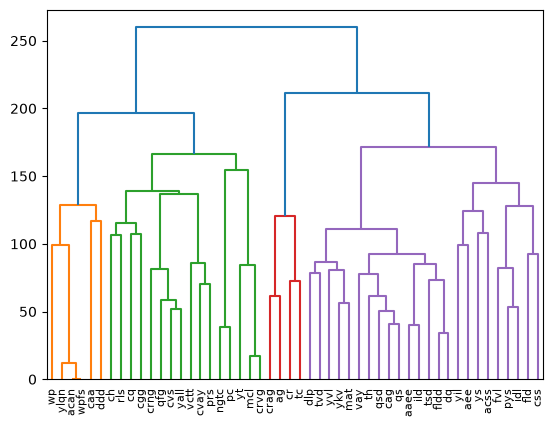

process completed in: 231.894895 seconds
[[('cac', np.float64(0.0), 1), ('dk', np.float64(0.0), 1), ('aw', np.float64(0.0), 1), ('ace', np.float64(0.0), 1), ('tin', np.float64(0.0), 1), ('ky', np.float64(0.0), 1), ('tt', np.float64(0.0), 1), ('ip', np.float64(0.0), 1), ('ph', np.float64(0.0), 1), ('glep', np.float64(0.0), 1), ('ipky', np.float64(0.0), 1), ('mldk', np.float64(0.0), 1), ('peg', np.float64(0.0), 1), ('ieh', np.float64(0.0), 1), ('vreg', np.float64(0.0), 1), ('vve', np.float64(0.0), 1), ('h', np.float64(0.0), 1), ('gle', np.float64(0.0), 1), ('cpeg', np.float64(0.0), 1), ('ks', np.float64(0.0), 1), ('vveip', np.float64(0.0), 1), ('ieie', np.float64(0.0), 1), ('cq', np.float64(0.0), 1), ('slee', np.float64(0.0), 1), ('hak', np.float64(0.0), 1), ('draw', np.float64(0.0), 1), ('en', np.float64(0.0), 1), ('cpdg', np.float64(0.0), 1), ('ch', np.float64(0.0), 1), ('slne', np.float64(0.0), 1), ('mp', np.float64(0.0), 1), ('hac', np.float64(0.0), 1), ('dll', np.float64(0.0), 1), (

In [7]:
from utility.worker_ppe_utility import multiplex_ppe

multiplex_ppe(cluster_ids = 1, vocab_sizes = vocab_sizes, max_workers = 2)

# In this step we perform segmentation of the ferredoxin sequences based on the steps we have trained already on Swiss-Prot

We pick the SWISS-Prot segmentation for the next steps.

## (ii) Discriminative Motif discovery

Using Chi-square test we find the most significant motifs related to the positive class

## (iii)  Motif visualizations

### Co-occurrences of motifs

Then we look at the co-occurrences pattern of the motifs on the positive set

In [29]:
vocab_binary

[('cac', np.float64(0.0)),
 ('dk', np.float64(0.0)),
 ('aw', np.float64(0.0)),
 ('ace', np.float64(0.0)),
 ('tin', np.float64(0.0)),
 ('ky', np.float64(0.0)),
 ('tt', np.float64(0.0)),
 ('ph', np.float64(0.0)),
 ('ip', np.float64(0.0)),
 ('glep', np.float64(0.0)),
 ('ipky', np.float64(0.0)),
 ('mldk', np.float64(0.0)),
 ('peg', np.float64(0.0)),
 ('ieh', np.float64(0.0)),
 ('vreg', np.float64(0.0)),
 ('vve', np.float64(0.0)),
 ('h', np.float64(0.0)),
 ('gle', np.float64(0.0)),
 ('cpeg', np.float64(0.0)),
 ('ks', np.float64(0.0)),
 ('vveip', np.float64(0.0)),
 ('ieie', np.float64(0.0)),
 ('cq', np.float64(0.0)),
 ('slee', np.float64(0.0)),
 ('hak', np.float64(0.0)),
 ('draw', np.float64(0.0)),
 ('en', np.float64(0.0)),
 ('cpdg', np.float64(0.0)),
 ('ch', np.float64(0.0)),
 ('slne', np.float64(0.0)),
 ('mp', np.float64(0.0)),
 ('hac', np.float64(0.0)),
 ('fd', np.float64(0.0)),
 ('dll', np.float64(0.0)),
 ('vlph', np.float64(0.0)),
 ('nh', np.float64(0.0)),
 ('ireg', np.float64(0.0)),
 (

In [31]:
# Save to disk
import pickle

with open('./example_vocab_binary.pkl', 'wb') as f:
    pickle.dump(vocab_binary, f)


In [8]:
# Read back
import pickle

with open('./example_vocab_binary.pkl', 'rb') as f:
    vocab_binary = pickle.load(f)

vocab_binary

with open('../datasets/sym_KL.pickle','rb') as f:
    DIST = pickle.load(f)

C:\Users\29sch\OneDrive\Documents\Silberg_Lab\Projects\dimotif\.venv\Lib\site-packages\scipy\cluster\hierarchy.py:335: ClusterWarning: The symmetric non-negative hollow observation matrix looks suspiciously like an uncondensed distance matrix
  return linkage(y, method='complete', metric='euclidean')


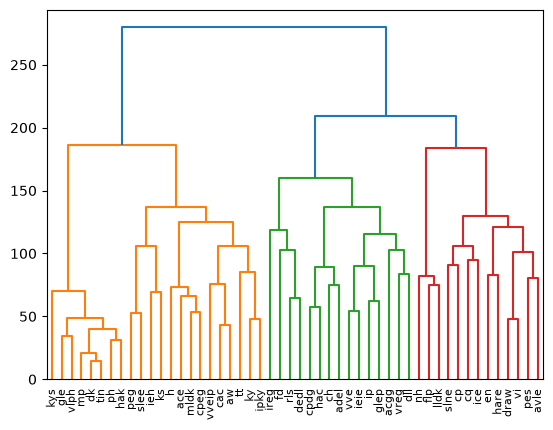

In [38]:
# tree of motifs
HC.nwk

'((((((((((((prs:86.24,vctt:86.24):10.24,yvll:96.48):17.64,pss:114.12):9.44,dal:123.56):23.46,(irlp:95.88,qse:95.88):51.14):25.92,((((pc:43.34,ngtc:43.34):33.97,kaeg:77.31):12.93,wil:90.24):8.38,glsr:98.62):74.33):33.59,((((((ss:83.88,acss:83.88):38.03,aee:121.91):2.35,((sgs:109.29,ty:109.29):9.09,qsfl:118.38):5.88):16.33,((vpd:82.87,yil:82.87):23.16,(dc:62.73,pts:62.73):43.30):34.57):17.93,((ikth:90.41,fld:90.41):14.48,((yqv:69.34,cvg:69.34):15.99,fall:85.32):19.57):53.63):11.12,((((vvie:83.55,wvl:83.55):11.65,(ags:50.18,css:50.18):45.02):10.17,kee:105.37):11.43,fgl:116.81):52.83):36.89):24.42,((((fs:87.98,ile:87.98):16.93,caa:104.91):30.60,ddd:135.50):22.33,(agl:127.93,qg:127.93):29.91):73.11):6.12,(((((((dede:23.69,vyel:23.69):14.19,cav:37.88):13.40,fgkg:51.29):11.25,qfg:62.54):5.85,qpe:68.39):14.95,(yall:57.55,cvs:57.55):25.79):41.17,(yprs:72.62,pfs:72.62):51.89):112.55):33.05,((((til:63.41,ytve:63.41):7.80,(((((fvg:12.99,iaqe:12.99):3.65,mcl:16.65):15.11,qpaa:31.76):4.99,kyp:36.75

### Visualization of co-occurence pattern

In [39]:
%matplotlib inline
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns; sns.set()

import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns


def create_mat_plot(
    mat,
    axis_names,
    title,
    filename,
    xlab,
    ylab,
    cmap="Blues",
    filetype=".png",
    rx=0,
    ry=0,
    font_s=10,
    annot=True,
):
    """Generates and saves a heatmap for 1D or 2D NumPy arrays without system TeX/dvipng dependencies."""
    # Ensure Matplotlib uses internal rendering (no external TeX/dvipng required)
    plt.rcParams["text.usetex"] = False

    # Convert 1D array to a 2D row matrix (1, N) for Seaborn
    mat = np.atleast_2d(mat)

    plt.figure()

    # Handle tick labels based on matrix dimensions
    if len(axis_names) > 0:
        xtick_labels = (
            axis_names if mat.shape[1] == len(axis_names) else "auto"
        )
        ytick_labels = (
            axis_names if mat.shape[0] == len(axis_names) else False
        )

        ax = sns.heatmap(
            mat,
            annot=annot,
            cmap=cmap,
            xticklabels=xtick_labels,
            yticklabels=ytick_labels,
        )
    else:
        ax = sns.heatmap(mat, annot=annot, cmap=cmap)

    # Set labels and title
    plt.title(title, fontsize=font_s)
    plt.xlabel(xlab, fontsize=font_s)
    plt.ylabel(ylab, fontsize=font_s)

    # Adjust tick font size and rotation
    plt.xticks(fontsize=font_s, rotation=rx)
    plt.yticks(fontsize=font_s, rotation=ry)

    # Save figure
    plt.tight_layout()
    plt.show()
    plt.savefig(f"{filename}.{filetype}", bbox_inches="tight")
    plt.close()

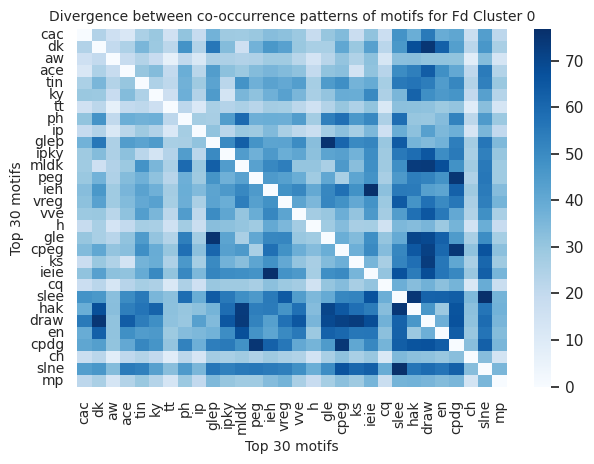

In [42]:
create_mat_plot(DIST[0:30,0:30], [x[0] for x in motifs[0:30]],'Divergence between co-occurrence patterns of motifs for Fd Cluster 0','Biofilm formation','Top 30 motifs','Top 30 motifs',annot=False, rx=90)

## Adding annotations related to secondary structure and other properties

In [43]:
from proteinseq_util.motif_properties import MotifProperties

In [44]:
MotifPropVis=MotifProperties()

In [ ]:
# get most probable structure of this motif in the PDB sequences
MotifPropVis.getMotifStructure('mgl')
#H = alpha helix
#B = residue in isolated beta-bridge
#E = extended strand, participates in beta ladder
#G = 3-helix (3/10 helix)
#I = 5 helix (pi helix)
#T = hydrogen bonded turn
#S = bend
#N = loop or other irregular structure

In [34]:
sec_classes,prop=MotifPropVis.get_motifs_pss_biophys(['mgl'])

100%|█████████████████████████████████████████████████████████████████| 1/1 [00:00<00:00, 9078.58it/s]


In [35]:
prop
# The order is the normalized
#['mean_molecular_weight',
# 'mean_flexibility',
# 'instability',
# 'mean_surface_accessibility',
# 'mean_kd_hydrophobicity',
# 'mean_hydrophilicity']

{'mgl': [-1.0114634864612668,
  np.float64(-0.28252406036752725),
  np.float64(-0.28258896805474465),
  np.float64(-0.970740175139044),
  np.float64(0.7751299216012043),
  np.float64(-0.4360941592403529)]}

#### if you have ete3 installed you can get the tree visualization as well

In [45]:
from proteinseq_util.motif_tree_visualization import VisualizeTreeOfMotifs

In [46]:
VT=VisualizeTreeOfMotifs(tree,[x[0] for x in motifs])

VT.create_circle('../datasets/'+'/biofilm_prop.pdf', 'BioFilm tree of motifs', ignore_branch_length=True)

  0%|                                                                                            | 0/50 [00:00<?, ?it/s]/home/ss307/.conda/envs/sci-env/lib/python3.10/site-packages/numpy/_core/fromnumeric.py:3860: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/home/ss307/.conda/envs/sci-env/lib/python3.10/site-packages/numpy/_core/_methods.py:145: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)
100%|████████████████████████████████████████████████████████████████████████████████| 50/50 [00:00<00:00, 31808.77it/s]


<img src="biofilm_prop.pdf">